3. Dataset https://archive.ics.uci.edu/ml/datasets/parkinsons
(a) Analyze and visualize the dataset to explore correlations and relationships among features
related to Parkinson’s disease.
(b) Build a classification model using K-Nearest Neighbors (KNN) and apply a variant approach
using Weighted KNN. Use the Elbow Method to determine the optimal value of k.
(c) Evaluate and interpret the model performance using Accuracy and Confusion Matrix metrics.

In [2]:
pip install ucimlrepo

In [3]:
# Parkinson's Disease Classification using KNN
# Dataset: UCI Parkinson's Dataset
# Install once if required:
# !pip install ucimlrepo
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [4]:
data = fetch_ucirepo(id=174)
X = data.data.features
y = data.data.targets["status"]

In [10]:
X

,MDVP:Fo,MDVP:Fhi,MDVP:Flo,MDVP:Jitter,MDVP:Jitter,MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer,...,MDVP:APQ,Shimmer:DDA,NHR,HNR,RPDE,DFA,spread1,spread2,D2,PPE
0,119.992,157.302,74.997,0.00784,0.00784,0.00370,0.00554,0.01109,0.04374,0.04374,...,0.02971,0.06545,0.02211,21.033,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,122.400,148.650,113.819,0.00968,0.00968,0.00465,0.00696,0.01394,0.06134,0.06134,...,0.04368,0.09403,0.01929,19.085,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,116.682,131.111,111.555,0.01050,0.01050,0.00544,0.00781,0.01633,0.05233,0.05233,...,0.03590,0.08270,0.01309,20.651,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,116.676,137.871,111.366,0.00997,0.00997,0.00502,0.00698,0.01505,0.05492,0.05492,...,0.03772,0.08771,0.01353,20.644,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,116.014,141.781,110.655,0.01284,0.01284,0.00655,0.00908,0.01966,0.06425,0.06425,...,0.04465,0.10470,0.01767,19.649,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,174.188,230.978,94.261,0.00459,0.00459,0.00263,0.00259,0.00790,0.04087,0.04087,...,0.02745,0.07008,0.02764,19.517,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,209.516,253.017,89.488,0.00564,0.00564,0.00331,0.00292,0.00994,0.02751,0.02751,...,0.01879,0.04812,0.01810,19.147,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,174.688,240.005,74.287,0.01360,0.01360,0.00624,0.00564,0.01873,0.02308,0.02308,...,0.01667,0.03804,0.10715,17.883,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,198.764,396.961,74.904,0.00740,0.00740,0.00370,0.00390,0.01109,0.02296,0.02296,...,0.01588,0.03794,0.07223,19.020,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [7]:
print("Dataset:")
print(X.head())

Dataset:
   MDVP:Fo  MDVP:Fhi  MDVP:Flo  MDVP:Jitter  MDVP:Jitter  MDVP:RAP  MDVP:PPQ  \
0  119.992   157.302    74.997      0.00784      0.00784   0.00370   0.00554   
1  122.400   148.650   113.819      0.00968      0.00968   0.00465   0.00696   
2  116.682   131.111   111.555      0.01050      0.01050   0.00544   0.00781   
3  116.676   137.871   111.366      0.00997      0.00997   0.00502   0.00698   
4  116.014   141.781   110.655      0.01284      0.01284   0.00655   0.00908   

   Jitter:DDP  MDVP:Shimmer  MDVP:Shimmer  ...  MDVP:APQ  Shimmer:DDA  \
0     0.01109       0.04374       0.04374  ...   0.02971      0.06545   
1     0.01394       0.06134       0.06134  ...   0.04368      0.09403   
2     0.01633       0.05233       0.05233  ...   0.03590      0.08270   
3     0.01505       0.05492       0.05492  ...   0.03772      0.08771   
4     0.01966       0.06425       0.06425  ...   0.04465      0.10470   

       NHR     HNR      RPDE       DFA   spread1   spread2        D2   

In [9]:
print("Dataset:")
print(y.head(50))

Dataset:
0     1
1     1
2     1
3     1
4     1
5     1
6     1
7     1
8     1
9     1
10    1
11    1
12    1
13    1
14    1
15    1
16    1
17    1
18    1
19    1
20    1
21    1
22    1
23    1
24    1
25    1
26    1
27    1
28    1
29    1
30    0
31    0
32    0
33    0
34    0
35    0
36    1
37    1
38    1
39    1
40    1
41    1
42    0
43    0
44    0
45    0
46    0
47    0
48    0
49    0
Name: status, dtype: int64


In [6]:
print("\nDataset Shape:")
print(X.shape)


Dataset Shape:
(195, 22)


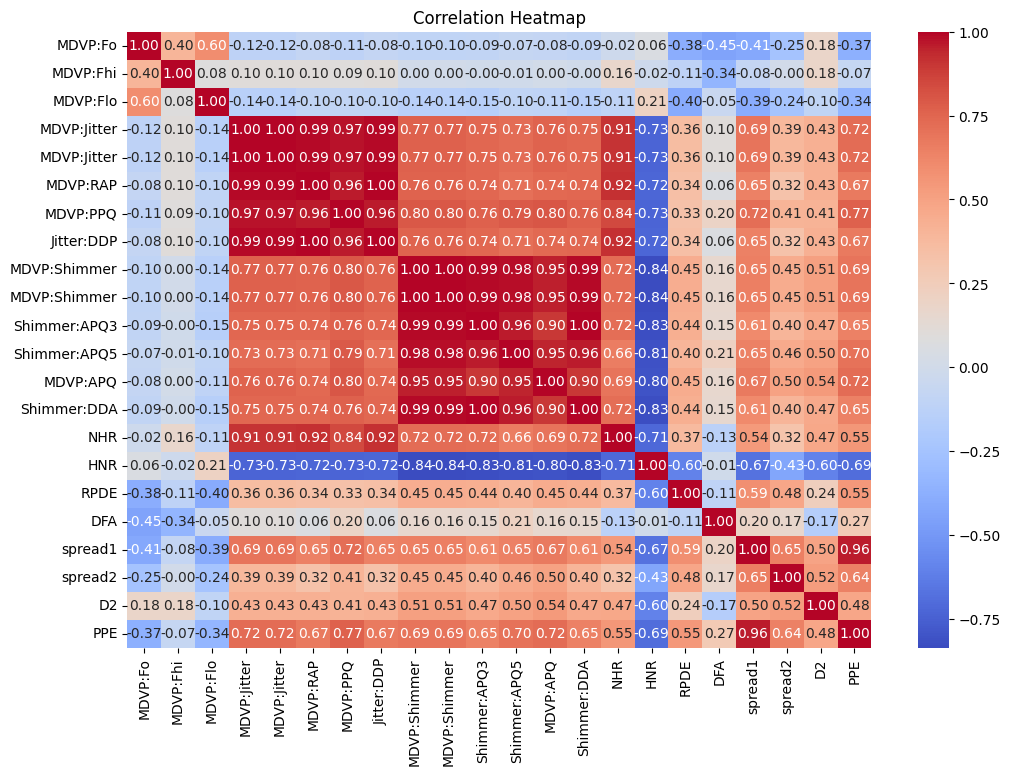

In [13]:
# Remove name column
#X1 = X.drop(columns=["name"])
correlation = X.corr()
plt.figure(figsize=(12, 8))
sns.heatmap(correlation,annot=True,
    cmap="coolwarm",
    fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

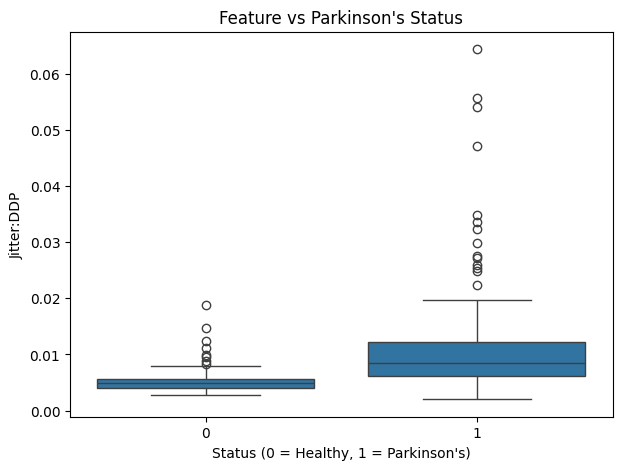

In [16]:
plt.figure(figsize=(7, 5))
sns.boxplot(
    x=y,
    y=X["Jitter:DDP"]
)
plt.xlabel("Status (0 = Healthy, 1 = Parkinson's)")
plt.ylabel("Jitter:DDP")
plt.title("Feature vs Parkinson's Status")
plt.show()

In [17]:
#Prepare Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
#Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [19]:
X_train.shape

(156, 22)

In [20]:
X_test.shape

(39, 22)

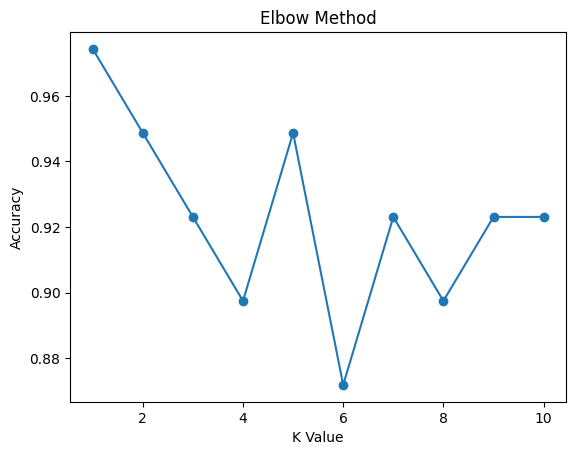

In [21]:
#Elbow Method
accuracy = []
for k in range(1, 11):
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    prediction = model.predict(X_test)
    acc = accuracy_score(y_test, prediction)
    accuracy.append(acc)
# Plot accuracy for different K values
plt.plot(range(1, 11), accuracy, marker="o")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Elbow Method")
plt.show()

Best K = 1

KNN Accuracy = 97.44 %

KNN Confusion Matrix:
[[ 7  0]
 [ 1 31]]


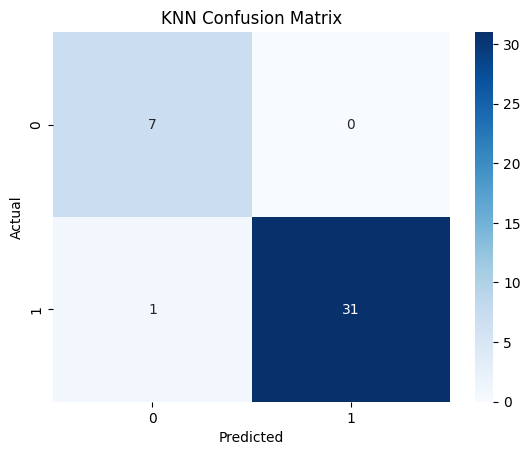


Weighted KNN Accuracy = 97.44 %

Weighted KNN Confusion Matrix:
[[ 7  0]
 [ 1 31]]


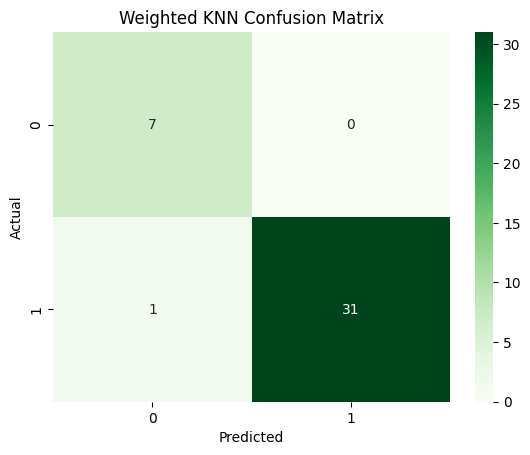

In [22]:

# Find best K
best_k = accuracy.index(max(accuracy)) + 1
print("Best K =", best_k)
#KNN Model
knn = KNeighborsClassifier(
    n_neighbors=best_k
)
knn.fit(X_train, y_train)
prediction = knn.predict(X_test)
acc = accuracy_score(
    y_test,
    prediction
)
print("\nKNN Accuracy =", round(acc * 100, 2), "%")
# Confusion Matrix
cm = confusion_matrix(
    y_test,
    prediction
)
print("\nKNN Confusion Matrix:")
print(cm)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("KNN Confusion Matrix")
plt.show()
#Weighted KNN
weighted_knn = KNeighborsClassifier(
    n_neighbors=best_k,
    weights="distance"
)
weighted_knn.fit(X_train, y_train)
weighted_prediction = weighted_knn.predict(X_test)
weighted_acc = accuracy_score(
    y_test,
    weighted_prediction
)
print(
    "\nWeighted KNN Accuracy =",
    round(weighted_acc * 100, 2),
    "%"
)
# Weighted KNN Confusion Matrix
cm2 = confusion_matrix(
    y_test,
    weighted_prediction
)
print("\nWeighted KNN Confusion Matrix:")
print(cm2)
sns.heatmap(
    cm2,
    annot=True,
    fmt="d",
    cmap="Greens"
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Weighted KNN Confusion Matrix")
plt.show()